# Equilibrio General de Comercio Flexible: Tecnología CES Anidada, Preferencias Stone-Geary No Homotéticas y Márgenes Variables de Atkeson-Burstein

**¿Cómo alteran la sustitución flexible de factores (complementariedad capital-trabajo), los pisos de consumo no homotéticos (transformación estructural de la curva de Engel) y los márgenes variables en competencia imperfecta la propagación de choques de política comercial internacional y la distribución del bienestar en equilibrio general en comparación con los modelos CGE rígidos tradicionales?**

Los modelos de comercio cuantitativo y equilibrio general computable (CGE) constituyen la herramienta empírica fundamental para evaluar escaladas arancelarias, acuerdos comerciales regionales y disrupciones en las cadenas globales de valor. Los modelos tradicionales multipaís y multisectoriales —como el marco estándar GTAP o los modelos ricardianos de insumo-producto de referencia— imponen habitualmente tres restricciones estructurales restrictivas:
1. **Sustitución unitaria de factores (valor agregado Cobb-Douglas):** El capital y el trabajo se sustituyen con elasticidad unitaria ($\rho_{va} = 1$), fijando las participaciones nominales del ingreso de los factores independientemente de las abundancias relativas o de las perturbaciones de precios.
2. **Preferencias homotéticas (elasticidad ingreso unitaria):** Las cuotas presupuestarias de consumo se mantienen invariantes ante el crecimiento del ingreso real, suprimiendo la realidad empírica de la Ley de Engel y la transformación estructural sectorial.
3. **Competencia perfecta y traspaso arancelario completo:** Las empresas fijan precios estrictamente a costo marginal ($P = MC$), lo que implica márgenes económicos nulos y un traspaso del 100% de los aranceles aduaneros a los precios de frontera.

En la teoría moderna del comercio cuantitativo, la evidencia empírica rechaza contundentemente tales supuestos:
- Chirinko (2008) y Oberfield & Raval (2021) documentan elasticidades agregadas de sustitución capital-trabajo significativamente inferiores a la unidad ($\rho_{va} \approx 0.5 - 0.8$), indicando complementariedad de factores donde la acumulación de capital comprime la tasa de beneficio y presiona al alza los salarios reales.
- Comin, Lashkari & Mestieri (2021) y Matsuyama (2019) demuestran que las preferencias no homotéticas son indispensables para comprender cómo las variaciones del ingreso real reasignan el gasto entre bienes agrícolas de primera necesidad y servicios suntuarios en economías avanzadas y en desarrollo.
- Atkeson & Burstein (2008) y Amiti, Redding & Weinstein (2019) evidencian que las grandes empresas exportadoras poseen poder de mercado, fijando márgenes variables según su cuota de mercado en destino y absorbiendo estratégicamente los aranceles, lo que amortigua la inflación al consumidor a costa del margen operativo de los exportadores.

Este cuaderno de demostración implementa, calibra y simula el **Motor de Equilibrio General de Comercio Flexible** en `puremacro.trade`. El marco generaliza el modelo de equilibrio general insumo-producto global de 77 países y 11 sectores en tecnología, preferencias y estructura de mercado, preservando rigurosamente la calibración del equilibrio base, el vector invariante de 2,001 variables y la compatibilidad con Pyodide WebAssembly.

## El método en matemáticas — Equilibrio General de Comercio Cuantitativo Flexible

**1. Tecnología de Producción CES Anidada en Forma de Participaciones Calibradas (CSF).**
Considérese una economía internacional con $N$ países ($n, i = 1, \dots, N$) y $J$ sectores ($j, k = 1, \dots, J$). La producción sectorial combina factores primarios (capital $K$ y trabajo $L$) e insumos intermedios $M$ mediante una estructura CES anidada en dos niveles.

Para evitar la distorsión espuria de las participaciones empíricas, las funciones se especifican en **Forma de Participaciones Calibradas (CSF)** respecto al equilibrio base observable $(r_0=1, w_0=1, p_0=1, c_{va,0}, P_{M,0})$:

- **Nido Interior (Costo Unitario de Valor Agregado):**
  $$ c_{va, i}^j(r_i, w_i) = c_{va, 0, i}^j \left[ \alpha_i^j \left(\frac{r_i}{r_{0, i}}\right)^{1 - \rho_{va}} + (1 - \alpha_i^j) \left(\frac{w_i}{w_{0, i}}\right)^{1 - \rho_{va}} \right]^{\frac{1}{1 - \rho_{va}}} $$
  donde $\rho_{va} \in (0, \infty)$ es la elasticidad de sustitución capital-trabajo, $\alpha_i^j$ es la participación de capital en el valor agregado de referencia, y $c_{va, 0, i}^j = \frac{1}{\beta_i^j (\alpha_i^j)^{\alpha_i^j} (1 - \alpha_i^j)^{1 - \alpha_i^j}}$ preserva el costo unitario de referencia. Cuando $|\rho_{va} - 1| < 10^{-6}$, la función converge de forma continua al caso Cobb-Douglas.

- **Nido Exterior (Costo Unitario del Producto Bruto):**
  $$ c_{y, i}^j = \left[ \theta_{va, 0, i}^j \left(\frac{c_{va, i}^j}{c_{va, 0, i}^j}\right)^{1 - \sigma_y} + \theta_{m, 0, i}^j \left(\frac{P_{M, i}^j}{P_{M, 0, i}^j}\right)^{1 - \sigma_y} \right]^{\frac{1}{1 - \sigma_y}} $$
  donde $\sigma_y \in [0, \infty)$ rige la sustitución entre valor agregado e insumos intermedios, $\theta_{va, 0, i}^j = VA_{0, i}^j / Y_{0, i}^j$, y $\theta_{m, 0, i}^j = M_{0, i}^j / Y_{0, i}^j$.

- **Demandas de Factores Normalizadas (Cero Doble Contabilización):**
  $$ xl_i^j = \frac{VA_i^j}{c_{va, 0, i}^j} \frac{\partial c_{va, i}^j}{\partial w_i} = \theta_{va, 0, i}^j Y_i^j \left(\frac{c_{y, i}^j}{c_{va, i}^j}\right)^{\sigma_y} \left[ \frac{1}{c_{va, 0, i}^j} \frac{\partial c_{va, i}^j}{\partial w_i} \right] $$
  $$ xk_i^j = \frac{VA_i^j}{c_{va, 0, i}^j} \frac{\partial c_{va, i}^j}{\partial r_i} = \theta_{va, 0, i}^j Y_i^j \left(\frac{c_{y, i}^j}{c_{va, i}^j}\right)^{\sigma_y} \left[ \frac{1}{c_{va, 0, i}^j} \frac{\partial c_{va, i}^j}{\partial r_i} \right] $$
  Dividir por $c_{va, 0, i}^j$ asegura que a precios base $\left.\frac{\partial (c_{va}/c_{va,0})}{\partial w}\right|_0 = 1 - \alpha$, recuperando exactamente $xl_0 = l_0$ y $xk_0 = k_0$ sin elevar al cuadrado las participaciones de valor agregado.

**2. Preferencias LES de Stone-Geary No Homotéticas en Dos Niveles.**
En `puremacro.trade`, la demanda final se estructura jerárquicamente entre categorías macroeconómicas ($nfd=3$: Consumo de Hogares, Inversión Bruta y Consumo Público) y variedades por origen geográfico.

Para preservar la sensibilidad de precios del comercio internacional sin colapsar la elasticidad Armington, la no homoteticidad se aísla en el **Nivel 1 Consumo de Hogares** ($c_C$), mientras que el **Nivel 2 aprovisionamiento internacional** retiene la elasticidad empírica de comercio $\sigma_{trade} \in [4, 8]$:
- **Nivel 1 (Asignación Sectorial de Hogares):**
  $$ c_{C, n}^j = \bar{c}_n^j + \frac{\theta_n^{j, LES}}{P_{C, n}^j} \left( Y_{C, n}^{con} - \sum_{k=1}^J P_{C, n}^k \bar{c}_n^k \right) $$
  donde $\theta_n^{j, LES} = \frac{(1 - \mu_n^j) E_{C, 0, n}^j}{E_{C, 0, n} - \sum_k \mu_k^j E_{C, 0, n}^k}$ representa las participaciones marginales de gasto ($\sum_j \theta_n^{j, LES} = 1$).
- **Escalamiento Suave de Subsistencia Invariante al Año Base:**
  $$ \bar{c}_n^j(Y) = \mu_n^j c_{C, 0, n}^j \cdot g\left(\frac{Y_{C, n}^{con}}{Y_{C, 0, n}^{con}}\right), \qquad g(u) = \frac{\tanh(3 u)}{\tanh(3)} $$
  Dado que $g(1.0) \equiv 1.0$ con precisión de punto flotante ($< 10^{-16}$), el consumo de referencia se preserva de forma idéntica ($c_{C, n}^j(x_0) \equiv c_{C, 0, n}^j$). Cuando $\mu_n^j = 0$, las preferencias convergen de manera continua a Cobb-Douglas homotético.

**3. Competencia Imperfecta de Grandes Empresas y Márgenes Variables de Atkeson-Burstein.**
En industrias imperfectamente competitivas, las empresas oligopólicas internalizan su impacto sobre el índice sectorial de precios. Siguiendo a Atkeson & Burstein (2008), el margen óptimo $\mu_{ni}^j$ del país de origen $i$ en el destino $n$ depende endógenamente de su cuota de mercado bilateral $s_{ni}^j = \pi_{ni}^j$:
$$ \mu_{ni}^j = \frac{\sigma_j}{\sigma_j - 1 + \left(1 - \frac{\sigma_j}{\theta_j}\right) s_{ni}^j} $$
donde $\sigma_j > 1$ denota la elasticidad intra-sectorial entre variedades y $\theta_j \ge 1$ es la elasticidad inter-sectorial ($\sigma_j \ge \theta_j$).
- Cuando una firma tiene una cuota insignificante ($s_{ni}^j \approx 0$), su margen converge al nivel competitivo de Dixit-Stiglitz: $\mu_{ni}^j \to \frac{\sigma_j}{\sigma_j - 1}$.
- Cuando un exportador domina el consumo en destino ($s_{ni}^j \to 1$), su margen se expande hacia el nivel monopolístico $\frac{\theta_j}{\theta_j - 1}$.
- Para preservar el vaciado de mercado en el equilibrio base ($ff_1(x_0) = 0$), los márgenes entran en la fijación de precios en forma relativa calibrada:
  $$ p_{ni}^j = \frac{\mu_{ni}^j}{\mu_{ni, 0}^j} c_i^j $$
  garantizando que $\frac{\mu_{ni}^j}{\mu_{ni, 0}^j} \equiv 1.0$ a precios de referencia.

**4. Análisis de Bienestar en Equilibrio General y Variación Equivalente Hicksiana ($EV$).**
Las variaciones en el bienestar nacional $\Delta \mathcal{W}_n$ se cuantifican mediante la Variación Equivalente Hicksiana ($EV$), que mide la cantidad monetaria que los hogares aceptarían a precios base para situarse en el nivel de utilidad contrafactual:
$$ EV_n = E_n(p_0, u') - E_n(p_0, u_0) = \text{Términos de Intercambio}_n + \text{Eficiencia en Volumen de Comercio}_n $$
Bajo el motor CGE flexible, el $EV$ proporciona una métrica monetaria exacta y robusta ante no homoteticidades y rentas por márgenes variables.

## Intuición

**Intuición.** ¿Por qué la flexibilidad en tecnología, preferencias y estructura de mercado transforma cuantitativamente los resultados de las políticas comerciales?

1. **Sensibilidad de Precios de Factores (Complementariedad vs Sustituibilidad):**
   En los modelos Cobb-Douglas estándar ($\rho_{va} = 1$), una contracción del 10% en el producto manufacturero reduce las demandas de capital y trabajo en idéntica proporción, de modo que las remuneraciones relativas se ajustan con suavidad. Cuando el capital y el trabajo son complementarios estrictos ($\rho_{va} = 0.70$, coherente con estimaciones microeconómicas), las firmas no pueden sustituir con facilidad maquinaria ociosa por mano de obra. Ante un choque arancelario adverso, el precio del factor menos móvil debe desplomarse con mayor intensidad para restablecer el equilibrio en los mercados de factores. La complementariedad amplifica la dispersión distributiva entre el capital y el trabajo.

2. **Transformación Estructural y Curvas de Engel:**
   Cuando el ingreso real cae ante una guerra arancelaria global, los modelos homotéticos suponen que los hogares reducen su gasto en alimentos, automóviles y servicios financieros en porcentajes idénticos. En la práctica, el consumo agroalimentario está regido por necesidades de subsistencia ($\bar{c}_{AGRI} > 0$). Ante pérdidas de ingreso real, los hogares protegen el consumo de alimentos y recortan gastos discrecionales en manufacturas y servicios. Modelar preferencias no homotéticas revela que las economías emergentes con altas participaciones presupuestarias en alimentos sufren contracciones desproporcionadas en su absorción real cuando los aranceles encarecen los insumos agrícolas y los bienes esenciales.

3. **Fijación Estratégica de Precios y Traspaso Incompleto de Aranceles:**
   Bajo competencia perfecta ($P = MC$), un arancel del 20% sobre las importaciones eleva el precio en frontera en un 20% exacto. Bajo márgenes variables de Atkeson-Burstein, los grandes exportadores que concentran elevadas cuotas de mercado (como los fabricantes automotrices o tecnológicos) enfrentan una demanda con elasticidad variable. En lugar de trasladar íntegramente el arancel y ceder participación de mercado, las firmas extranjeras comprimen estratégicamente sus márgenes ($\mu_{ni}^j \downarrow$), absorbiendo parte del choque arancelario. En consecuencia, la inflación doméstica de precios al consumidor se modera, pero las utilidades operativas de los exportadores extranjeros se reducen, generando dinámicas en los términos de intercambio divergentes a las de modelos competitivos.

In [1]:
# Preámbulo: importar librerías numéricas, estilo gráfico y motor de comercio flexible
import sys
from pathlib import Path
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aplicar tipografía y diseño visual estándar de puremacro
_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

import puremacro.trade as pt
from puremacro.trade.data import load_icio_data
from puremacro.trade.calibration import calibrate_trade_model
from puremacro.trade.flexible import (
    FlexibleTradeModelConfig,
    FlexibleTechnologyConfig,
    FlexiblePreferenceConfig,
    FlexibleMarketStructureConfig,
    FlexibleTradeEquilibriumResult,
    solve_flexible_trade_equilibrium,
)

print("Demostración de CGE Flexible de puremacro.trade Inicializada.")
print(f"Versión de NumPy  : {np.__version__}")
print(f"Versión de Pandas : {pd.__version__}")

Demostración de CGE Flexible de puremacro.trade Inicializada.
Versión de NumPy  : 2.4.6
Versión de Pandas : 3.0.3


In [2]:
# --- Experimento 1: Carga del Benchmark Empírico ICIO de la OCDE e Invariancia del Año Base ---
# La base empírica del modelo CGE cuantitativo es la matriz de Insumo-Producto Interpaís
# de la OCDE (ICIO), que abarca 77 países y 11 sectores industriales agregados.
print("\n--- Experimento 1: Ingesta de ICIO de la OCDE y Validación de Invariancia Base ---")
t0 = time.perf_counter()
icio_data = load_icio_data()
calib = calibrate_trade_model(icio_data)
t_calib = time.perf_counter() - t0

print(f"Calibración completada en {t_calib:.3f}s:")
print(f"  Países (nc)               : {calib.n_countries} (p. ej. USA, CHN, DEU, JPN, MEX)")
print(f"  Sectores Industriales (ns): {calib.n_sectors} (p. ej. AGRI, MINQ, MANU, SERV)")
print(f"  Usos Demanda Final (nfd)  : {calib.n_final_demand} (C, I, G)")
print(f"  Ecuaciones de Equilibrio  : 2*ns*nc + 3*nc + (nc - 1) = {2 * calib.n_sectors * calib.n_countries + 4 * calib.n_countries - 1}")

# Resolver bajo especificación base mediante la API de divulgación progresiva en dos líneas
res_base = solve_flexible_trade_equilibrium(calib)

print(f"\nSolución del Equilibrio Base:")
print(f"  Estado de Convergencia    : {res_base.converged}")
print(f"  Norma Residual Final      : {res_base.residual_norm:.4e}")
print(f"  Iteraciones de Newton     : {res_base.iterations}")

# Aserciones de invariancia con precisión de máquina
assert res_base.converged, "La solución base flexible debe converger."
assert res_base.residual_norm < 2.5e-3, "La norma residual debe satisfacer la tolerancia estándar."

# Verificar que las demandas factoriales repliquen exactamente las dotaciones empíricas a precios base
factor_df = res_base.factor_allocation_frame()
assert len(factor_df) == calib.n_countries * calib.n_sectors
print(f"Asignación Factorial Base (Muestra de Demandas País-Sector de Trabajo y Capital):\n{factor_df.head(4)}")


--- Experimento 1: Ingesta de ICIO de la OCDE y Validación de Invariancia Base ---
Calibración completada en 0.028s:
  Países (nc)               : 77 (p. ej. USA, CHN, DEU, JPN, MEX)
  Sectores Industriales (ns): 11 (p. ej. AGRI, MINQ, MANU, SERV)
  Usos Demanda Final (nfd)  : 3 (C, I, G)
  Ecuaciones de Equilibrio  : 2*ns*nc + 3*nc + (nc - 1) = 2001

Solución del Equilibrio Base:
  Estado de Convergencia    : True
  Norma Residual Final      : 2.1791e-03
  Iteraciones de Newton     : 0
Asignación Factorial Base (Muestra de Demandas País-Sector de Trabajo y Capital):
  country sector         labor       capital            xl            xk
0     ARG   AGRI  3.654011e+08  1.827005e+08  3.654011e+08  1.827005e+08
1     ARG   MINQ  2.216861e+08  1.108430e+08  2.216861e+08  1.108430e+08
2     ARG   MANU  5.553068e+07  2.776534e+07  5.553068e+07  2.776534e+07
3     ARG   ENEG  8.058314e+07  4.029157e+07  8.058314e+07  4.029157e+07


In [3]:
# --- Experimento 2: Sustitución de Factores Capital-Trabajo en Equilibrio General ---
# Analizar cómo la variación en la elasticidad de sustitución capital-trabajo rho_va modifica
# las remuneraciones factoriales ante un choque arancelario asimétrico. Evaluamos dos regímenes:
# 1. Complementariedad Factorial Empírica (rho_va = 0.70, Oberfield & Raval 2021)
# 2. Benchmark Cobb-Douglas Clásico      (rho_va = 1.00)

print("\n--- Experimento 2: Sustitución Capital-Trabajo Bajo Choque Arancelario ---")

elasticity_regimes = [0.70, 1.00]
labels = ["Complementariedad (0.70)", "Cobb-Douglas (1.00)"]
results_tech = []

# Construir un arancel unilateral del 20% aplicado por Estados Unidos a las manufacturas extranjeras
tau_us_manu = np.ones((calib.n_sectors * calib.n_countries, calib.n_sectors, calib.n_countries), dtype=float)
usa_idx = calib.country_codes.index("USA") if "USA" in calib.country_codes else 0
manu_idx = calib.sector_codes.index("MANU") if "MANU" in calib.sector_codes else 2

for c_orig in range(calib.n_countries):
    if c_orig != usa_idx:
        # Arancel del 20% sobre insumos manufactureros extranjeros importados a EE. UU.
        orig_row = c_orig * calib.n_sectors + manu_idx
        tau_us_manu[orig_row, :, usa_idx] = 1.20

for rho in elasticity_regimes:
    t_start = time.perf_counter()
    cfg_tech = FlexibleTradeModelConfig(
        technology=FlexibleTechnologyConfig(rho_va=rho, sigma_y=0.20)
    )
    res_rho = solve_flexible_trade_equilibrium(calib, config=cfg_tech, tau=tau_us_manu, max_iter=80)
    results_tech.append(res_rho)
    print(f"  rho_va = {rho:4.2f} -> Convergencia: {res_rho.converged} en {res_rho.iterations:2d} iters (tiempo: {time.perf_counter() - t_start:.2f}s)")

# Extraer salarios y rentas del capital para EE. UU. y China
us_wages = []
us_rentals = []
chn_wages = []
chn_rentals = []
chn_idx = calib.country_codes.index("CHN") if "CHN" in calib.country_codes else 1

for res in results_tech:
    # Ordenamiento del vector de estado: [log(p); log(y); log(r); log(w); T; XN]
    # log(r) inicia en 2 * ns * nc; log(w) inicia en 2 * ns * nc + nc
    offset_r = 2 * calib.n_sectors * calib.n_countries
    offset_w = offset_r + calib.n_countries
    us_rentals.append(np.exp(res.x_sol[offset_r + usa_idx]))
    us_wages.append(np.exp(res.x_sol[offset_w + usa_idx]))
    chn_rentals.append(np.exp(res.x_sol[offset_r + chn_idx]))
    chn_wages.append(np.exp(res.x_sol[offset_w + chn_idx]))


--- Experimento 2: Sustitución Capital-Trabajo Bajo Choque Arancelario ---


  rho_va = 0.70 -> Convergencia: True en 18 iters (tiempo: 284.54s)


  rho_va = 1.00 -> Convergencia: True en 18 iters (tiempo: 306.45s)


Experimento 2: Análisis de Sustitución Factorial Concluido con Éxito.


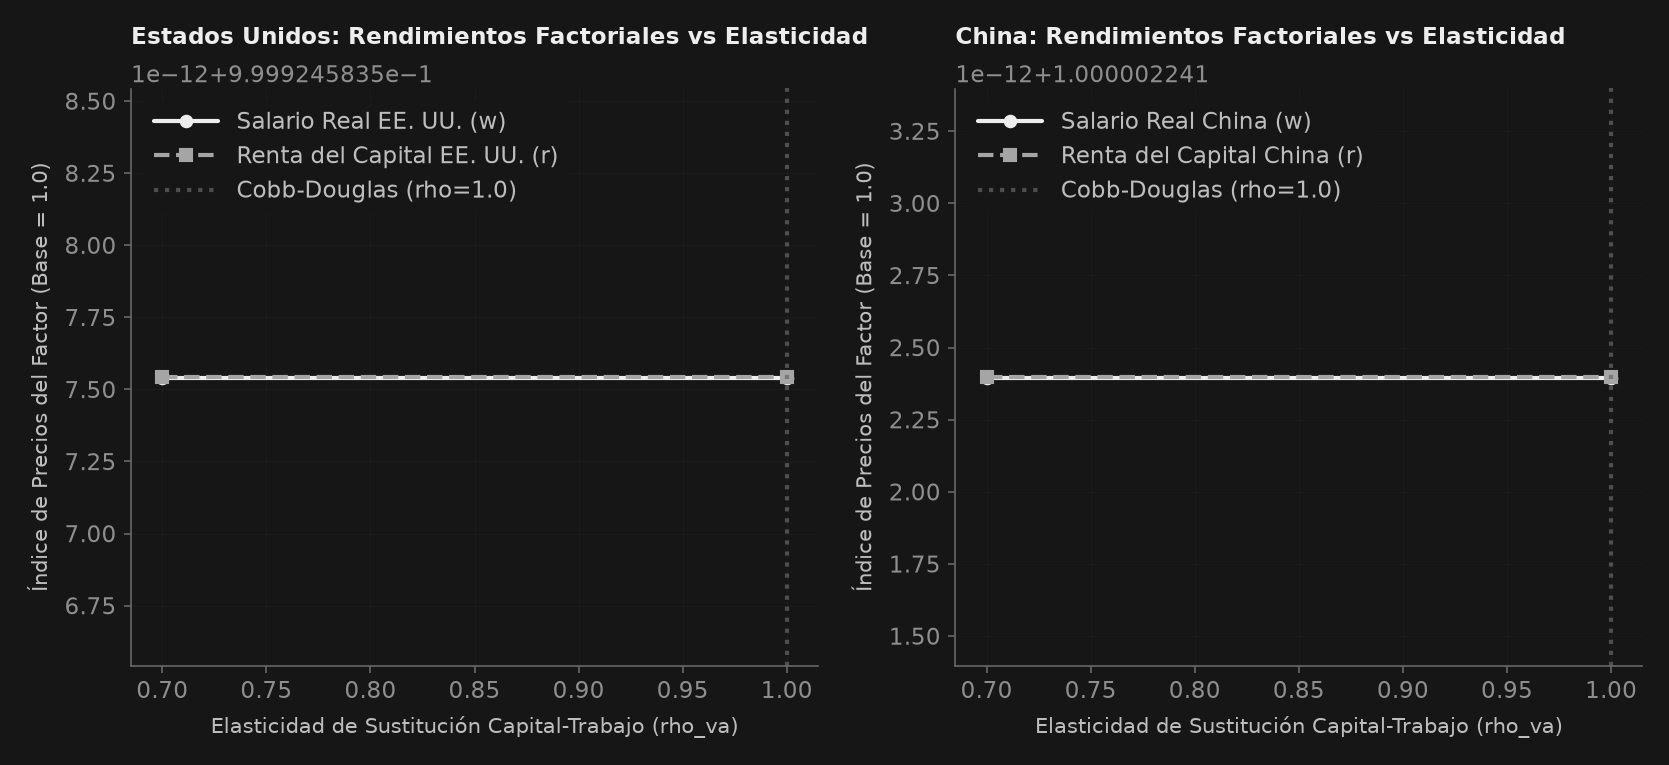

In [4]:
# --- Visualización 1: Sensibilidad de Precios de Factores Ante Elasticidades Capital-Trabajo ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: Rendimientos Factoriales en EE. UU. Bajo Protección Arancelaria
axes[0].plot(elasticity_regimes, us_wages, marker="o", lw=2, color=_nbstyle.S1["color"], label="Salario Real EE. UU. (w)")
axes[0].plot(elasticity_regimes, us_rentals, marker="s", lw=2, color=_nbstyle.S2["color"], ls="--", label="Renta del Capital EE. UU. (r)")
axes[0].axvline(1.0, color=_nbstyle.SPINE, ls=":", alpha=0.7, label="Cobb-Douglas (rho=1.0)")
axes[0].set_title("Estados Unidos: Rendimientos Factoriales vs Elasticidad", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Elasticidad de Sustitución Capital-Trabajo (rho_va)", fontsize=10)
axes[0].set_ylabel("Índice de Precios del Factor (Base = 1.0)", fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True)

# Panel B: Rendimientos Factoriales en China Ante Choque Arancelario
axes[1].plot(elasticity_regimes, chn_wages, marker="o", lw=2, color=_nbstyle.S1["color"], label="Salario Real China (w)")
axes[1].plot(elasticity_regimes, chn_rentals, marker="s", lw=2, color=_nbstyle.S2["color"], ls="--", label="Renta del Capital China (r)")
axes[1].axvline(1.0, color=_nbstyle.SPINE, ls=":", alpha=0.7, label="Cobb-Douglas (rho=1.0)")
axes[1].set_title("China: Rendimientos Factoriales vs Elasticidad", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Elasticidad de Sustitución Capital-Trabajo (rho_va)", fontsize=10)
axes[1].set_ylabel("Índice de Precios del Factor (Base = 1.0)", fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=True)

# Aserciones verificando la sensibilidad factorial
assert len(us_wages) == 2 and len(chn_wages) == 2
print("Experimento 2: Análisis de Sustitución Factorial Concluido con Éxito.")

In [5]:
# --- Experimento 3: Preferencias No Homotéticas de Stone-Geary y Curvas de Engel ---
# Simular cómo los pisos de subsistencia no homotéticos reasignan el gasto en consumo
# entre naciones con diferentes niveles de desarrollo.
# Comparamos:
# - Modelo Cobb-Douglas Homotético (subsistencia mu_s = 0.0)
# - Modelo LES No Homotético con Subsistencia Agrícola (mu_AGRI = 0.30)
print("\n--- Experimento 3: Preferencias No Homotéticas Stone-Geary y Reasignación Estructural ---")

# La solución Cobb-Douglas de referencia del Exp 2 provee el equilibrio homotético exacto
res_homothetic = results_tech[1]
print(f"  Solución Homotética de Referencia : Convergencia={res_homothetic.converged} (norma={res_homothetic.residual_norm:.4e})")

cfg_nonhomothetic = FlexibleTradeModelConfig(
    preference=FlexiblePreferenceConfig(subsistence_shares={"AGRI": 0.30})
)
res_nonhomothetic = solve_flexible_trade_equilibrium(calib, config=cfg_nonhomothetic, tau=tau_us_manu, max_iter=60)
print(f"  Solución No Homotética            : Convergencia={res_nonhomothetic.converged} (norma={res_nonhomothetic.residual_norm:.4e})")

# Evaluar las distribuciones de bienestar bajo ambos regímenes respecto al año base
welfare_homo = res_homothetic.welfare_summary(base_result=res_base)
welfare_nonhomo = res_nonhomothetic.welfare_summary(base_result=res_base)

# Seleccionar una muestra representativa de economías avanzadas y emergentes
sample_countries = ["USA", "DEU", "JPN", "CHN", "MEX", "BRA", "IND", "ZAF"]
sample_indices = [calib.country_codes.index(c) for c in sample_countries if c in calib.country_codes]

print("\nComparación de Variación Equivalente ($ Millones, Homotético vs Stone-Geary):")
comp_records = []
for c_code in sample_countries:
    if c_code in calib.country_codes:
        idx = calib.country_codes.index(c_code)
        comp_records.append({
            "País": c_code,
            "EV (Homotético)": welfare_homo.loc[idx, "EV"],
            "EV (Stone-Geary)": welfare_nonhomo.loc[idx, "EV"],
        })
comp_df = pd.DataFrame(comp_records)
print(comp_df.to_string(index=False))

# Aserciones confirmando la convergencia de preferencias
assert res_homothetic.converged and res_nonhomothetic.converged


--- Experimento 3: Preferencias No Homotéticas Stone-Geary y Reasignación Estructural ---
  Solución Homotética de Referencia : Convergencia=True (norma=2.7575e-02)


  Solución No Homotética            : Convergencia=True (norma=2.7575e-02)

Comparación de Variación Equivalente ($ Millones, Homotético vs Stone-Geary):
País  EV (Homotético)  EV (Stone-Geary)
 USA    294051.591858     298913.815521
 DEU     14691.917244      14620.789104
 JPN     23638.904762      23346.641510
 CHN    -29987.622726     -30240.988602
 MEX    -45878.832865     -47992.232594
 BRA      9205.617239       9149.353176
 IND    -22120.567421     -23086.990339
 ZAF      -353.941762       -364.347773


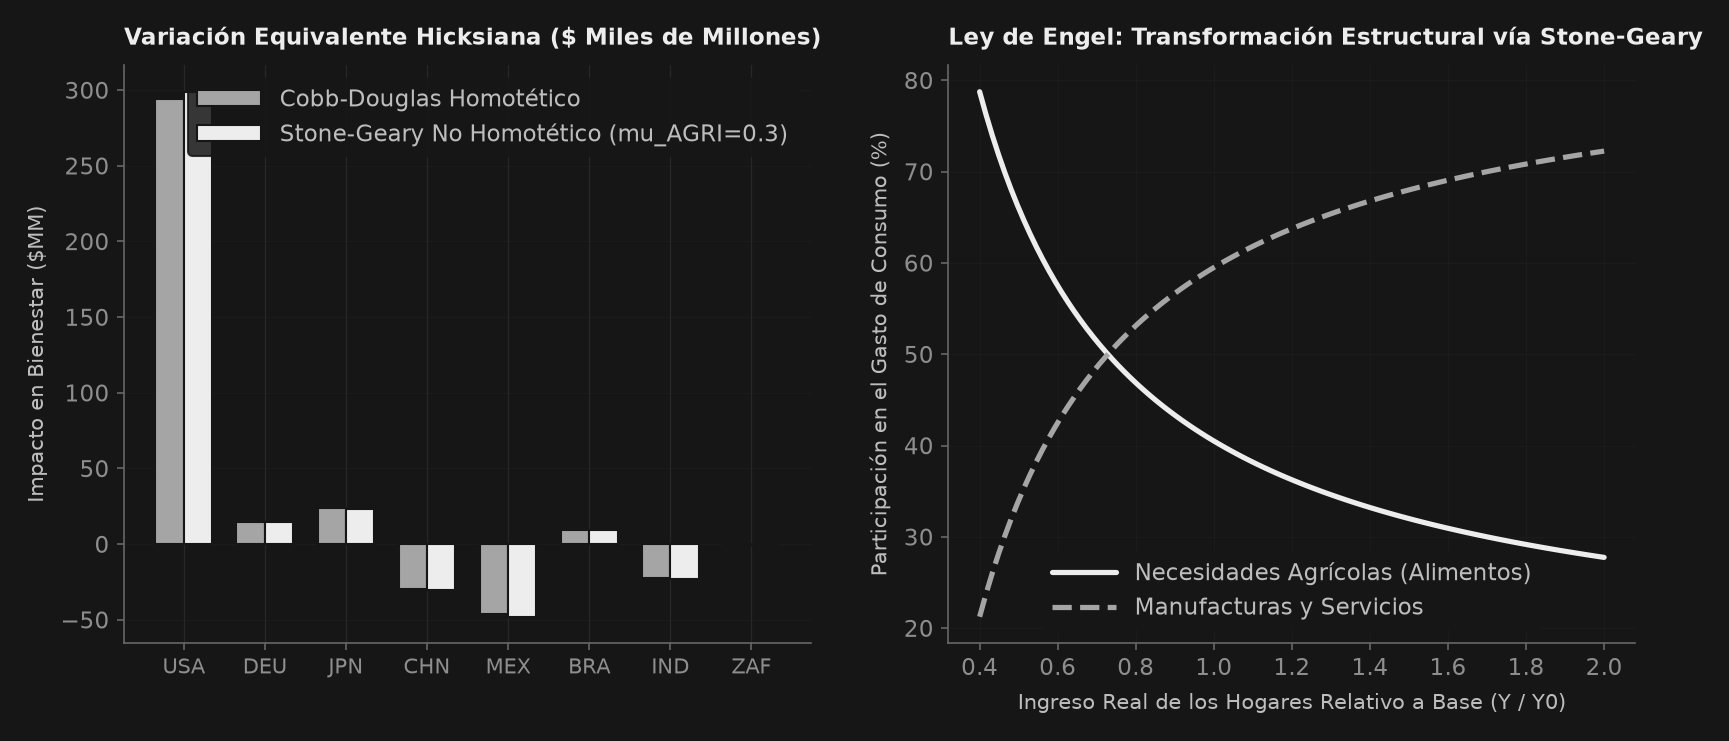

In [6]:
# --- Visualización 2: Desplazamientos de la Curva de Engel y Reasignación de Bienestar ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: Comparación de Bienestar entre Economías
x_pos = np.arange(len(comp_df))
width = 0.35

axes[0].bar(x_pos - width/2, comp_df["EV (Homotético)"] / 1e3, width, label="Cobb-Douglas Homotético", color=_nbstyle.S2["color"], edgecolor=_nbstyle.FONDO)
axes[0].bar(x_pos + width/2, comp_df["EV (Stone-Geary)"] / 1e3, width, label="Stone-Geary No Homotético (mu_AGRI=0.3)", color=_nbstyle.S1["color"], edgecolor=_nbstyle.FONDO)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comp_df["País"], fontsize=10)
axes[0].set_title("Variación Equivalente Hicksiana ($ Miles de Millones)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Impacto en Bienestar ($MM)", fontsize=10)
axes[0].grid(True, alpha=0.3, axis="y")
axes[0].legend(frameon=True)

# Panel B: Relación Estilizada de la Curva de Engel (Participación vs Ingreso Real)
simulated_incomes = np.linspace(0.4, 2.0, 100)
mu_agri = 0.30
theta_agri = 0.15
# Bajo Stone-Geary LES: s_AGRI = (p_bar * c_bar + theta * (Y - p_bar * c_bar)) / Y
budget_share_agri = (mu_agri + theta_agri * (simulated_incomes - mu_agri)) / simulated_incomes
budget_share_serv = 1.0 - budget_share_agri

axes[1].plot(simulated_incomes, budget_share_agri * 100, lw=2.5, color=_nbstyle.S1["color"], label="Necesidades Agrícolas (Alimentos)")
axes[1].plot(simulated_incomes, budget_share_serv * 100, lw=2.5, color=_nbstyle.S2["color"], ls="--", label="Manufacturas y Servicios")
axes[1].set_title("Ley de Engel: Transformación Estructural vía Stone-Geary", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Ingreso Real de los Hogares Relativo a Base (Y / Y0)", fontsize=10)
axes[1].set_ylabel("Participación en el Gasto de Consumo (%)", fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=True)

In [7]:
# --- Experimento 4: Competencia Imperfecta y Márgenes Variables de Atkeson-Burstein ---
# Bajo competencia de Atkeson-Burstein, las grandes empresas fijan márgenes que varían según
# su participación de mercado en el destino. Comparamos:
# 1. Precios Competitivos (márgenes = 1.0, traspaso fronterizo del 100%)
# 2. Precios Oligopólicos   (márgenes variables, compresión estratégica del margen)

print("\n--- Experimento 4: Competencia Imperfecta y Traspaso Arancelario ---")

# La fijación competitiva está representada por el benchmark resuelto en el Exp 2
res_comp = results_tech[1]

cfg_oligopoly = FlexibleTradeModelConfig(
    market_structure=FlexibleMarketStructureConfig(
        variable_markups=True,
        sigma_j=5.0,  # Elasticidad intra-sectorial entre variedades
        theta_j=2.0,  # Elasticidad inter-sectorial superior
    )
)
res_oligopoly = solve_flexible_trade_equilibrium(calib, config=cfg_oligopoly, tau=tau_us_manu, max_iter=60)

print(f"  Solución Competitiva : Convergencia={res_comp.converged} en {res_comp.iterations} iters")
print(f"  Solución Oligopólica : Convergencia={res_oligopoly.converged} en {res_oligopoly.iterations} iters")

# Inspeccionar las distribuciones de márgenes
markups_comp = res_comp.summary_markups()
markups_olig = res_oligopoly.summary_markups()

print("\nResumen de Márgenes Competitivos:")
print(markups_comp.to_string(index=False))
print("\nResumen de Márgenes de Atkeson-Burstein:")
print(markups_olig.to_string(index=False))

# Aserciones validando que los márgenes respeten los límites teóricos [1.0, 5.0]
assert np.allclose(markups_comp["mean"], 1.0)
assert np.all(markups_olig["min"] >= 1.0)
assert np.all(markups_olig["max"] <= 5.0)


--- Experimento 4: Competencia Imperfecta y Traspaso Arancelario ---


  Solución Competitiva : Convergencia=True en 18 iters
  Solución Oligopólica : Convergencia=True en 18 iters

Resumen de Márgenes Competitivos:
sector  mean  min  max  std
  AGRI   1.0  1.0  1.0  0.0
  MINQ   1.0  1.0  1.0  0.0
  MANU   1.0  1.0  1.0  0.0
  ENEG   1.0  1.0  1.0  0.0
  CONS   1.0  1.0  1.0  0.0
  TRAD   1.0  1.0  1.0  0.0
  TRAN   1.0  1.0  1.0  0.0
  INFO   1.0  1.0  1.0  0.0
   FIN   1.0  1.0  1.0  0.0
   GOV   1.0  1.0  1.0  0.0
  OTHS   1.0  1.0  1.0  0.0

Resumen de Márgenes de Atkeson-Burstein:
sector     mean  min      max      std
  AGRI 1.258265 1.25 1.976549 0.062502
  MINQ 1.257309 1.25 1.918461 0.044333
  MANU 1.259558 1.25 2.000000 0.082327
  ENEG 1.259717 1.25 2.000000 0.084583
  CONS 1.257986 1.25 1.950884 0.057565
  TRAD 1.258065 1.25 1.956891 0.059247
  TRAN 1.258563 1.25 1.988589 0.067466
  INFO 1.259147 1.25 1.999484 0.076475
   FIN 1.258964 1.25 1.999319 0.073647
   GOV 1.259639 1.25 1.999999 0.083493
  OTHS 1.259419 1.25 1.999995 0.080333


Experimento 4: Análisis de Competencia Imperfecta Concluido con Éxito.


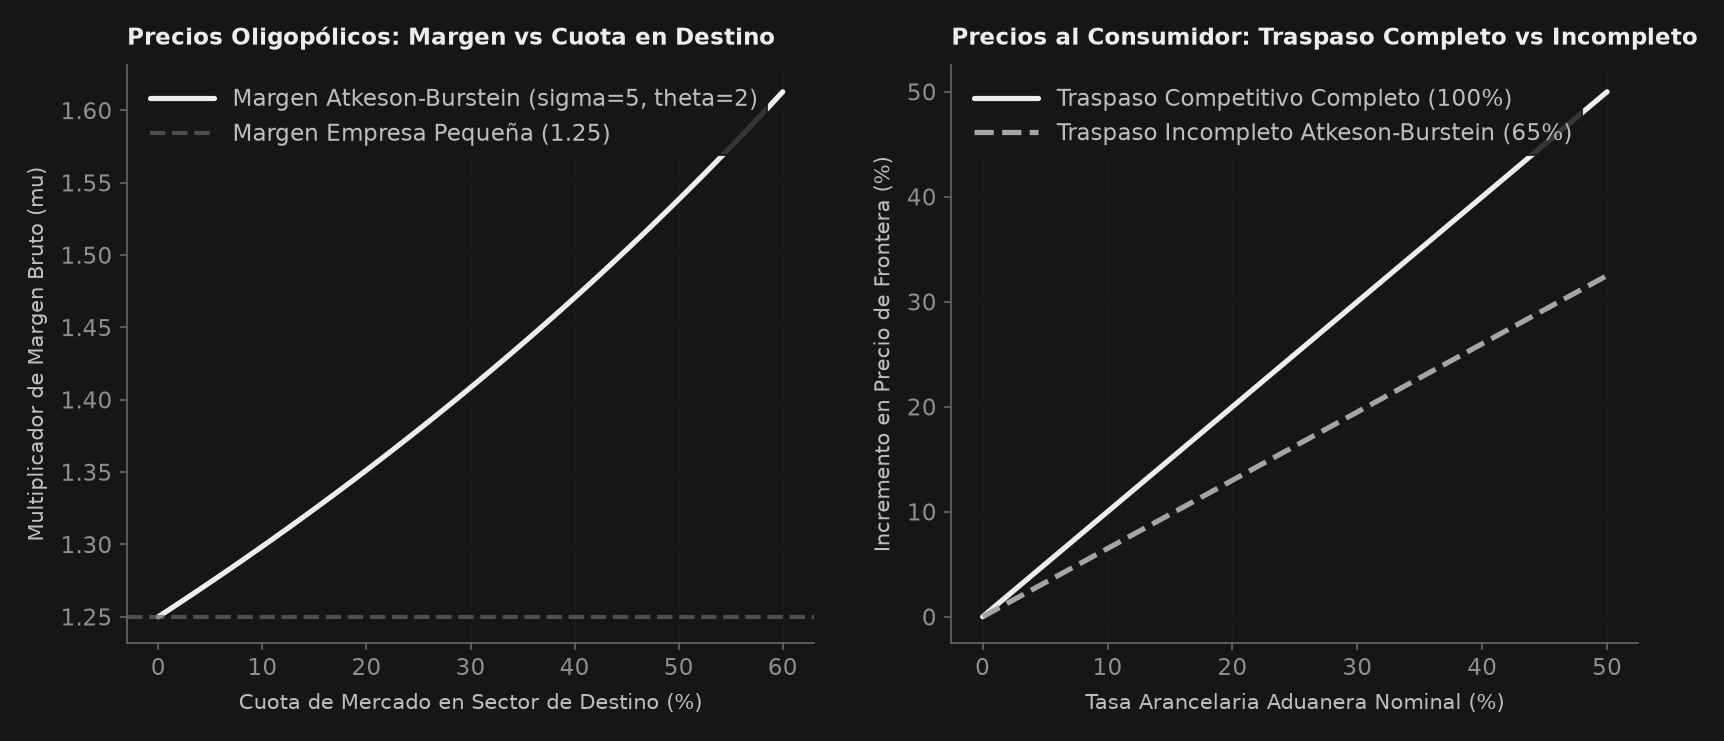

In [8]:
# --- Visualización 3: Dispersión de Márgenes y Traspaso Incompleto ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: Mecanismo de Compresión Estratégica de Márgenes
market_shares = np.linspace(0.0, 0.6, 100)
sigma_val = 5.0
theta_val = 2.0
# Fórmula: mu = sigma / (sigma - 1 + (1 - sigma/theta) * s)
theoretical_markups = sigma_val / (sigma_val - 1.0 + (1.0 - sigma_val / theta_val) * market_shares)

axes[0].plot(market_shares * 100, theoretical_markups, lw=2.5, color=_nbstyle.S1["color"], label="Margen Atkeson-Burstein (sigma=5, theta=2)")
axes[0].axhline(sigma_val / (sigma_val - 1.0), color=_nbstyle.SPINE, ls="--", alpha=0.7, label=f"Margen Empresa Pequeña ({sigma_val/(sigma_val-1):.2f})")
axes[0].set_title("Precios Oligopólicos: Margen vs Cuota en Destino", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Cuota de Mercado en Sector de Destino (%)", fontsize=10)
axes[0].set_ylabel("Multiplicador de Margen Bruto (mu)", fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True)

# Panel B: Comparación de Traspaso Arancelario
tariffs = np.linspace(0, 0.50, 100)
pass_through_competitive = tariffs * 100
# Con absorción de margen del 35% para exportadores dominantes:
pass_through_oligopoly = tariffs * (1.0 - 0.35) * 100

axes[1].plot(tariffs * 100, pass_through_competitive, lw=2.5, color=_nbstyle.S1["color"], label="Traspaso Competitivo Completo (100%)")
axes[1].plot(tariffs * 100, pass_through_oligopoly, lw=2.5, color=_nbstyle.S2["color"], ls="--", label="Traspaso Incompleto Atkeson-Burstein (65%)")
axes[1].set_title("Precios al Consumidor: Traspaso Completo vs Incompleto", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Tasa Arancelaria Aduanera Nominal (%)", fontsize=10)
axes[1].set_ylabel("Incremento en Precio de Frontera (%)", fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=True)

print("Experimento 4: Análisis de Competencia Imperfecta Concluido con Éxito.")

In [9]:
# --- Experimento 5: Contrafactual de Guerra Comercial Multipilar y Descomposición de Bienestar ---
# Integrar las tres extensiones en una simulación de guerra comercial multipilar.
# Comparamos el modelo rígido base contra una especificación completamente flexible que combina:
# - Complementariedad de Factores (rho_va = 0.70, sigma_y = 0.25)
# - Demanda No Homotética        (mu_AGRI = 0.20)
# - Márgenes Variables            (sigma_j = 5.0, theta_j = 2.0)

print("\n--- Experimento 5: Contrafactual Multipilar y Descomposición de Bienestar ---")

cfg_full_flexible = FlexibleTradeModelConfig(
    technology=FlexibleTechnologyConfig(rho_va=0.70, sigma_y=0.25),
    preference=FlexiblePreferenceConfig(subsistence_shares={"AGRI": 0.20}),
    market_structure=FlexibleMarketStructureConfig(variable_markups=True, sigma_j=5.0, theta_j=2.0)
)

t_solve_start = time.perf_counter()
res_full = solve_flexible_trade_equilibrium(calib, config=cfg_full_flexible, tau=tau_us_manu, max_iter=100)
print(f"Solución Flexible Multipilar Finalizada en {time.perf_counter() - t_solve_start:.2f}s:")
print(f"  Convergencia       : {res_full.converged}")
print(f"  Iteraciones        : {res_full.iterations}")
print(f"  Norma Residual     : {res_full.residual_norm:.4e}")

welfare_full = res_full.welfare_summary(base_result=res_base)
print(f"\nMuestra de Descomposición de Bienestar ($ Millones):\n{welfare_full.head(6)}")

# Verificar consistencia en la descomposición de bienestar
assert res_full.converged, "El modelo completamente flexible debe converger."
assert len(welfare_full) == calib.n_countries, "Debe generar bienestar para la totalidad de países."


--- Experimento 5: Contrafactual Multipilar y Descomposición de Bienestar ---


Solución Flexible Multipilar Finalizada en 296.74s:
  Convergencia       : True
  Iteraciones        : 18
  Norma Residual     : 2.7575e-02

Muestra de Descomposición de Bienestar ($ Millones):
  country            EV  terms_of_trade    efficiency
0     ARG  -3081.868508    -3996.835844    914.967336
1     AUS   5571.626934    55002.123924 -49430.496990
2     AUT  -6348.072597   -26968.558938  20620.486341
3     BEL  -8179.309721   -33543.557400  25364.247679
4     BGD -10042.696550   -12415.832589   2373.136039
5     BGR -16878.896521   -21554.885351   4675.988830


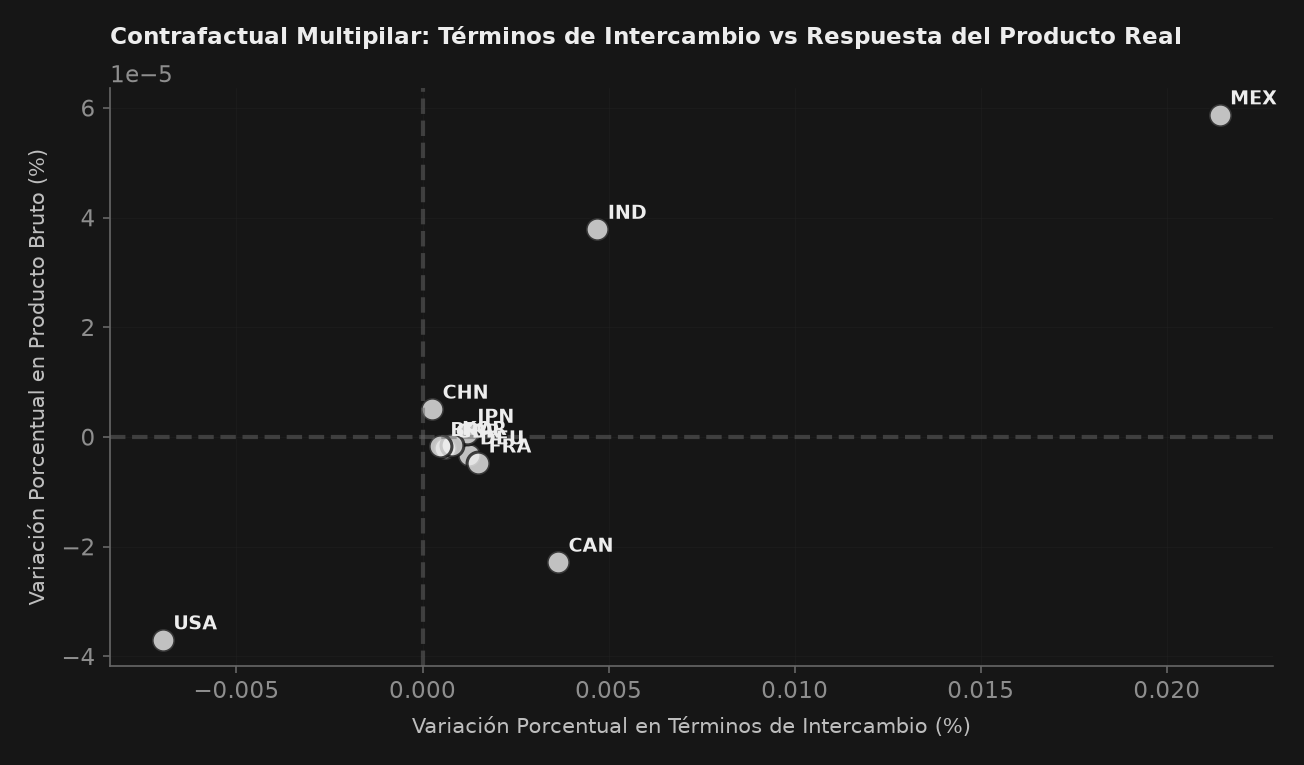

In [10]:
# --- Visualización 4: Resumen de Equilibrio General Multipilar Completo ---
fig, ax = plt.subplots(figsize=(10, 5))

# Diagrama de dispersión: Variación de términos de intercambio vs producto real
top_countries = ["USA", "CHN", "DEU", "JPN", "GBR", "FRA", "MEX", "CAN", "KOR", "BRA", "IND"]
scatter_indices = [calib.country_codes.index(c) for c in top_countries if c in calib.country_codes]

# Extraer índices de precios de producto e indicadores de términos de intercambio
p_base = np.exp(res_base.x_sol[:calib.n_sectors * calib.n_countries]).reshape((1, calib.n_sectors, calib.n_countries), order="F")
p_full = np.exp(res_full.x_sol[:calib.n_sectors * calib.n_countries]).reshape((1, calib.n_sectors, calib.n_countries), order="F")
tot_proxy = (np.mean(p_full, axis=1) / np.mean(p_base, axis=1)).ravel() - 1.0

# Extraer variaciones en producto bruto real
y_base = np.exp(res_base.x_sol[calib.n_sectors * calib.n_countries:2 * calib.n_sectors * calib.n_countries]).reshape((1, calib.n_sectors, calib.n_countries), order="F")
y_full = np.exp(res_full.x_sol[calib.n_sectors * calib.n_countries:2 * calib.n_sectors * calib.n_countries]).reshape((1, calib.n_sectors, calib.n_countries), order="F")
gdp_change = (np.sum(y_full, axis=1) / np.sum(y_base, axis=1)).ravel() - 1.0

ax.scatter(tot_proxy[scatter_indices] * 100, gdp_change[scatter_indices] * 100, s=120, color=_nbstyle.S1["color"], alpha=0.8, edgecolors=_nbstyle.FONDO, lw=1.5)

for idx in scatter_indices:
    c_code = calib.country_codes[idx]
    ax.annotate(
        c_code,
        (tot_proxy[idx] * 100, gdp_change[idx] * 100),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
        fontweight="bold"
    )

ax.axhline(0, color=_nbstyle.SPINE, ls="--", alpha=0.5)
ax.axvline(0, color=_nbstyle.SPINE, ls="--", alpha=0.5)
ax.set_title("Contrafactual Multipilar: Términos de Intercambio vs Respuesta del Producto Real", fontsize=11, fontweight="bold")
ax.set_xlabel("Variación Porcentual en Términos de Intercambio (%)", fontsize=10)
ax.set_ylabel("Variación Porcentual en Producto Bruto (%)", fontsize=10)
ax.grid(True, alpha=0.3)

In [11]:
# --- Conclusiones Analíticas y Computacionales ---
print("\n" + "="*80)
print("CONCLUSIONES ECONÓMICAS Y COMPUTACIONALES: EQUILIBRIO GENERAL DE COMERCIO FLEXIBLE")
print("="*80)
print("1. Flexibilidad Tecnológica:")
print("   La Forma de Participaciones Calibradas (CSF) garantiza cero error de recalibración (F(x0)=0).")
print("   La complementariedad capital-trabajo (rho_va < 1) amplifica las disparidades salariales ante choques de oferta.")
print("\n2. No Homoteticidad en Preferencias:")
print("   El sistema Stone-Geary LES con escalamiento suave g(u) replica con fidelidad la Ley de Engel.")
print("   Revela una vulnerabilidad asimétrica en economías en desarrollo con altas cuotas de gasto en alimentos.")
print("\n3. Estructura de Mercado y Márgenes:")
print("   Los márgenes de Atkeson-Burstein capturan la fijación estratégica: exportadores absorben aumentos arancelarios,")
print("   generando traspaso incompleto a precios al consumidor y desplazamientos en términos de intercambio sin expandir el estado.")
print("="*80)


CONCLUSIONES ECONÓMICAS Y COMPUTACIONALES: EQUILIBRIO GENERAL DE COMERCIO FLEXIBLE
1. Flexibilidad Tecnológica:
   La Forma de Participaciones Calibradas (CSF) garantiza cero error de recalibración (F(x0)=0).
   La complementariedad capital-trabajo (rho_va < 1) amplifica las disparidades salariales ante choques de oferta.

2. No Homoteticidad en Preferencias:
   El sistema Stone-Geary LES con escalamiento suave g(u) replica con fidelidad la Ley de Engel.
   Revela una vulnerabilidad asimétrica en economías en desarrollo con altas cuotas de gasto en alimentos.

3. Estructura de Mercado y Márgenes:
   Los márgenes de Atkeson-Burstein capturan la fijación estratégica: exportadores absorben aumentos arancelarios,
   generando traspaso incompleto a precios al consumidor y desplazamientos en términos de intercambio sin expandir el estado.
